In [1]:
# Verbindung zu Google Drive aufbauen
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install geopandas rasterio shapely

In [5]:
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 42.3 MB/s eta 0:00:00


In [6]:
import matplotlib as mpl
# APA 7 konforme Abbildungen

# Schrift
mpl.rcParams["font.family"]      = "serif"
mpl.rcParams["font.serif"]  = ["Liberation Serif", "DejaVu Serif", "Georgia"]
mpl.rcParams["font.size"]        = 12       # Grundschriftgröße
mpl.rcParams["axes.titlesize"]   = 12       # Titel
mpl.rcParams["axes.labelsize"]   = 11       # Achsenbeschriftung
mpl.rcParams["xtick.labelsize"]  = 10       # X-Achse Ticks
mpl.rcParams["ytick.labelsize"]  = 10       # Y-Achse Ticks
mpl.rcParams["legend.fontsize"]  = 10       # Legende
mpl.rcParams["figure.titlesize"] = 12       # Suptitle

# Linien & Achsen
mpl.rcParams["axes.linewidth"]   = 0.8      # Achsenrahmen
mpl.rcParams["xtick.major.width"]= 0.8
mpl.rcParams["ytick.major.width"]= 0.8
mpl.rcParams["lines.linewidth"]  = 1.0

# Hintergrund & Gitter
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.grid"]        = False    # APA: kein Gitter

# Abbildungsgröße & Auflösung
mpl.rcParams["figure.dpi"]       = 150
mpl.rcParams["savefig.dpi"]      = 300      # APA: mind. 300 dpi beim Speichern
mpl.rcParams["savefig.bbox"]     = "tight"
mpl.rcParams["savefig.format"]   = "png"

# Legende
mpl.rcParams["legend.frameon"]       = False   # APA: kein Rahmen um Legende
mpl.rcParams["legend.loc"]           = "best"

print("✅ APA 7 Stil gesetzt – Times New Roman, 300 dpi, kein Gitter")

✅ APA 7 Stil gesetzt – Times New Roman, 300 dpi, kein Gitter


In [7]:
# SETUP
import os
import glob
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from shapely.geometry import box
from shapely.ops import unary_union
import fiona
import shapely
from shapely.geometry import shape

# ── Basispfade ────────────────────────────────────────────────────────────────
base     = "/content/drive/MyDrive/Colab_Notebooks"
shp_dir  = f"{base}/Shapefiles_Gebiete"
dgm_dir  = f"{base}/DGM"
lod2_dir = f"{base}/LoD2/original"

target_crs = "EPSG:25832"

grafik_dir_gebiete = f"{base}/Grafiken/Gebiete"
os.makedirs(grafik_dir_gebiete, exist_ok=True)

NODATA   = -9999.0

# ── Shapefiles ────────────────────────────────────────────────────────────────
alkis_path = f"{base}/ALKIS/ALKIS_Stadt_Wue/ALKIS_Stadt_Wue.shp"
gebiete_pfade = {
    "Rottenbauer-Nord":     f"{shp_dir}/Rottenbauer/Shape_Rottenbauer_Nord.shp",
    "Rottenbauer-Süd":      f"{shp_dir}/Rottenbauer/Shape_Rottenbauer_alt.shp",
    "Lengfeld":             f"{shp_dir}/Lengfeld/Shape_Lengfeld.shp",
    "Lengfeld-Kern":        f"{shp_dir}/Lengfeld/Shape_Lengfeld_alt.shp",
    "Hubland Grünfläche":   f"{shp_dir}/Hubland/Shape_Hubland_Gruenflaeche.shp",
    "Hubland Terrassen":    f"{shp_dir}/Hubland/Shape_Hublandterrassen.shp",
    "Hubland Quartier I":   f"{shp_dir}/Hubland/Shape_Quartier_I.shp",
    "Hubland Quartier II":  f"{shp_dir}/Hubland/Shape_Quartier_II_plus_BBP_70.shp",
    "Hubland Quartier III": f"{shp_dir}/Hubland/Shape_Quartier_III.shp",
    "Gartenstadt":          f"{shp_dir}/Gartenstadt/Shape_Gartenstadt.shp",
}

# ── Daten laden ───────────────────────────────────────────────────────────────
alkis  = gpd.read_file(alkis_path)
gebiete = {name: gpd.read_file(path) for name, path in gebiete_pfade.items()}

# ── Hubland-Gesamt zusammenführen ─────────────────────────────────────────────
hubland_keys = ["Hubland Grünfläche", "Hubland Terrassen",
                "Hubland Quartier I", "Hubland Quartier II", "Hubland Quartier III"]
hubland_gesamt = gpd.GeoDataFrame(
    geometry=[pd.concat([gebiete[k].geometry for k in hubland_keys]).union_all()],
    crs=gebiete[hubland_keys[0]].crs
)

gebiete_final = {}
for name, gdf in gebiete.items():
    gebiete_final[name] = gdf
    if name == "Hubland Quartier III":
        gebiete_final["Hubland-Gesamt"] = hubland_gesamt

# ── DGM Mosaik ───────────────────────────────────────────────────────────────
dgm_pfade  = glob.glob(f"{dgm_dir}/*.tif")
src_files  = [rasterio.open(p) for p in dgm_pfade]
mosaic, mosaic_transform = merge(src_files)
mosaic_crs  = src_files[0].crs
mosaic_data = mosaic[0].astype(float)
nodata_val  = src_files[0].nodata
if nodata_val is not None:
    mosaic_data[mosaic_data == nodata_val] = np.nan
for src in src_files:
    src.close()

print(f" ALKIS geladen  | CRS: {alkis.crs}")
print(f" {len(gebiete_final)} Untersuchungsgebiete geladen")
print(f" {len(dgm_pfade)} DGM-Kacheln zu Mosaik zusammengeführt | CRS: {mosaic_crs}")

 ALKIS geladen  | CRS: EPSG:25832
 11 Untersuchungsgebiete geladen
 15 DGM-Kacheln zu Mosaik zusammengeführt | CRS: EPSG:25832


In [8]:
# ── Flächen der Untersuchungsgebiete ─────────────────────────────────────────
print("Flächen der Untersuchungsgebiete:")
print("=" * 45)
for name, gdf in gebiete_final.items():
    m2 = gdf.geometry.area.sum()
    print(f"  {name:<25} {m2:>12,.0f} m²   {m2/10_000:>7.2f} ha")

Flächen der Untersuchungsgebiete:
  Rottenbauer-Nord               413,308 m²     41.33 ha
  Rottenbauer-Süd                428,374 m²     42.84 ha
  Lengfeld                       160,542 m²     16.05 ha
  Lengfeld-Kern                  219,055 m²     21.91 ha
  Hubland Grünfläche             210,563 m²     21.06 ha
  Hubland Terrassen               45,383 m²      4.54 ha
  Hubland Quartier I              62,038 m²      6.20 ha
  Hubland Quartier II             29,569 m²      2.96 ha
  Hubland Quartier III           144,656 m²     14.47 ha
  Hubland-Gesamt                 491,596 m²     49.16 ha
  Gartenstadt                    431,234 m²     43.12 ha


In [9]:
# Mittlere Höhe pro Gebiet (DGM)
def mean_elevation(gdf):
    geoms = list(gdf.to_crs(mosaic_crs).geometry)
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(driver="GTiff", height=mosaic_data.shape[0],
                          width=mosaic_data.shape[1], count=1,
                          dtype=mosaic_data.dtype, crs=mosaic_crs,
                          transform=mosaic_transform, nodata=np.nan) as ds:
            ds.write(mosaic_data, 1)
        with memfile.open() as ds:
            clipped, _ = mask(ds, geoms, crop=True, nodata=np.nan)
    werte = clipped[0][~np.isnan(clipped[0])]
    return np.mean(werte) if len(werte) > 0 else np.nan

print("Durchschnittliche Höhe über Meeresspiegel")
print("=" * 45)
for name, gdf in gebiete_final.items():
    print(f"  {name:<25} {mean_elevation(gdf):>6.1f} m ü. NN")

Durchschnittliche Höhe über Meeresspiegel
  Rottenbauer-Nord           276.2 m ü. NN
  Rottenbauer-Süd            274.9 m ü. NN
  Lengfeld                   256.7 m ü. NN
  Lengfeld-Kern              214.6 m ü. NN
  Hubland Grünfläche         259.2 m ü. NN
  Hubland Terrassen          259.9 m ü. NN
  Hubland Quartier I         250.8 m ü. NN
  Hubland Quartier II        253.5 m ü. NN
  Hubland Quartier III       258.6 m ü. NN
  Hubland-Gesamt             257.7 m ü. NN
  Gartenstadt                266.6 m ü. NN


In [10]:
# DGM-Abdeckungscheck
kachel_polygone = []
kachel_namen    = []
with rasterio.open(dgm_pfade[0]) as src:
    dgm_crs = src.crs

for p in dgm_pfade:
    with rasterio.open(p) as src:
        b = src.bounds
        kachel_polygone.append(box(b.left, b.bottom, b.right, b.top))
        kachel_namen.append(os.path.basename(p))

dgm_kacheln     = gpd.GeoDataFrame({"name": kachel_namen},
                                    geometry=kachel_polygone, crs=dgm_crs)
gebiete_reproj  = {name: gdf.to_crs(dgm_crs) for name, gdf in gebiete_final.items()}
dgm_union       = dgm_kacheln.geometry.union_all()

# Automatischer Check
print("\n Abdeckungscheck:")
print("=" * 55)
for name, gdf in gebiete_reproj.items():
    gebiet_union = gdf.geometry.union_all()
    abdeckung    = dgm_union.intersection(gebiet_union).area / gebiet_union.area * 100
    status       = "✅" if abdeckung >= 99 else "⚠️  UNVOLLSTÄNDIG"
    print(f"  {status} {name:<25} {abdeckung:.1f}% abgedeckt")


 Abdeckungscheck:
  ✅ Rottenbauer-Nord          99.1% abgedeckt
  ✅ Rottenbauer-Süd           100.0% abgedeckt
  ✅ Lengfeld                  100.0% abgedeckt
  ✅ Lengfeld-Kern             100.0% abgedeckt
  ✅ Hubland Grünfläche        100.0% abgedeckt
  ✅ Hubland Terrassen         100.0% abgedeckt
  ✅ Hubland Quartier I        100.0% abgedeckt
  ✅ Hubland Quartier II       100.0% abgedeckt
  ⚠️  UNVOLLSTÄNDIG Hubland Quartier III      98.2% abgedeckt
  ✅ Hubland-Gesamt            99.5% abgedeckt
  ✅ Gartenstadt               100.0% abgedeckt


In [11]:
# ── LoD2 laden ────────────────────────────────────────────────────────────────
def lade_lod2_fiona(path, layer="Building"):
    rows = []
    with fiona.open(path, layer=layer) as src:
        crs = src.crs
        for feature in src:
            props = dict(feature["properties"])
            try:
                props["geometry"] = shapely.force_2d(shape(feature["geometry"]))
            except:
                props["geometry"] = None
            rows.append(props)
    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)
    return gdf[gdf.geometry.notna()]

print("🔄 Lade LoD2-Kacheln...")
kacheln = []
for f in sorted(os.listdir(lod2_dir)):
    if not f.endswith(".gml"):
        continue
    try:
        gdf = lade_lod2_fiona(os.path.join(lod2_dir, f))
        kacheln.append(gdf)
        print(f"  ✔ {f}: {len(gdf):,} Gebäude")
    except Exception as e:
        print(f"  ❌ {f}: {e}")

lod2_gesamt = gpd.GeoDataFrame(
    pd.concat(kacheln, ignore_index=True), crs=kacheln[0].crs
).to_crs(target_crs)

# ── Funktionscode übersetzen ──────────────────────────────────────────────────
function_mapping = {
    "31001_1000": "Wohngebäude",
    "31001_2000": "Sonstiges Gebäude",
    "31001_2463": "Garage / Carport",
    "31001_2523": "Nebengebäude",
    "31001_3000": "Öffentliches Gebäude",
    "31001_3012": "Rathaus",
    "31001_3020": "Schule / Bildung",
    "31001_3041": "Krankenhaus",
    "31001_3065": "Sportgebäude",
    "31001_3072": "Freizeitgebäude",
    "31001_9998": "Unbekannt",
    "51009_1610": "Sonstiges Gebäude",
    "53001_1800": "Landwirtschaft",
}
lod2_gesamt["funktion_de"] = lod2_gesamt["function"].map(function_mapping).fillna("Unbekannt")
print(f"\n✅ LoD2 gesamt: {len(lod2_gesamt):,} Gebäude")

# ── Farbschemata ──────────────────────────────────────────────────────────────
alkis_farben = {
    "Wohnbaufläche":                          "#f5c0c0",
    "Fläche gemischter Nutzung":              "#f0d080",
    "Fläche besonderer funktionaler Prägung": "#d4aad4",
    "Industrie- und Gewerbefläche":           "#c0a0c0",
    "Bahnverkehr":                            "#aaaaaa",
    "Straßenverkehr":                         "#cccccc",
    "Weg":                                    "#dddddd",
    "Platz":                                  "#e8e8e8",
    "Grünanlage":                             "#c8e6c8",
    "Sport-, Freizeit- und Erholungsfläche":  "#a8d8a8",
    "Gehölz":                                 "#90c090",
    "Wald":                                   "#7fbf7f",
    "Landwirtschaft":                         "#f0e080",
    "Fließgewässer":                          "#a0c8f0",
    "Stehendes Gewässer":                     "#80b8e8",
    "Unland/Vegetationslose Fläche":          "#e0d8c8",
}
lod2_farben = {
    "Wohngebäude":          "#c0392b",
    "Sonstiges Gebäude":    "#7f8c8d",
    "Garage / Carport":     "#e67e22",
    "Nebengebäude":         "#d4a96a",
    "Öffentliches Gebäude": "#2980b9",
    "Schule / Bildung":     "#1a6fa8",
    "Krankenhaus":          "#8e44ad",
    "Sportgebäude":         "#27ae60",
    "Freizeitgebäude":      "#1e8449",
    "Landwirtschaft":       "#b7950b",
    "Unbekannt":            "#bdc3c7",
}

# ── Paarweise ALKIS + LoD2 Karten ────────────────────────────────────────────
paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]

for neubau, bestand in paare:
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    for ax, name, gruppe in [
        (axes[0], neubau,  "Neubaugebiet"),
        (axes[1], bestand, "Bestandssiedlung"),
    ]:
        gdf        = gebiete_final[name].to_crs(target_crs)
        alkis_clip = gpd.clip(alkis, gdf)
        lod2_clip  = gpd.clip(lod2_gesamt, gdf)

        alkis_clip = alkis_clip.copy()
        lod2_clip  = lod2_clip.copy()
        alkis_clip["farbe"] = alkis_clip["nutzart"].map(alkis_farben).fillna("#e0e0e0")
        lod2_clip["farbe"]  = lod2_clip["funktion_de"].map(lod2_farben).fillna("#bdc3c7")

        alkis_clip.plot(ax=ax, color=alkis_clip["farbe"],
                        edgecolor="white", linewidth=0.3, zorder=1)
        if len(lod2_clip) > 0:
            lod2_clip.plot(ax=ax, color=lod2_clip["farbe"],
                           edgecolor="black", linewidth=0.4, alpha=0.85, zorder=2)
        gdf.boundary.plot(ax=ax, color="black", linewidth=2.0, zorder=3)

        ax.set_title(f"{name}\n({gruppe})",
                     fontsize=12, fontweight="bold", color="black")
        ax.axis("off")

    # ── Gemeinsame Legende ────────────────────────────────────────────────────
    gdf_n = gebiete_final[neubau].to_crs(target_crs)
    gdf_b = gebiete_final[bestand].to_crs(target_crs)

    vorhandene_nutzarten  = (set(gpd.clip(alkis, gdf_n)["nutzart"].dropna()) |
                             set(gpd.clip(alkis, gdf_b)["nutzart"].dropna()))
    vorhandene_funktionen = (set(gpd.clip(lod2_gesamt, gdf_n)["funktion_de"].dropna()) |
                             set(gpd.clip(lod2_gesamt, gdf_b)["funktion_de"].dropna()))

    alkis_patches = [
        mpatches.Patch(facecolor=alkis_farben.get(k, "#e0e0e0"),
                       edgecolor="none", label=k)
        for k in sorted(vorhandene_nutzarten)
    ]
    lod2_patches = [
        mpatches.Patch(facecolor=lod2_farben.get(k, "#bdc3c7"),
                       edgecolor="black", linewidth=0.5, label=k)
        for k in sorted(vorhandene_funktionen)
    ]

    alle_handles = (
        [mpatches.Patch(visible=False, label="ALKIS Nutzart:")] +
        alkis_patches +
        [mpatches.Patch(visible=False, label=" ")] +
        [mpatches.Patch(visible=False, label="LoD2 Gebäudefunktion:")] +
        lod2_patches
    )

    fig.legend(
        handles=alle_handles,
        loc="lower center",
        ncol=5,
        fontsize=8,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        handlelength=1.2,
        handleheight=1.0,
    )

    fig.suptitle(
        f"Paarvergleich: {neubau} vs. {bestand}\n"
        "ALKIS Nutzart & LoD2 Gebäudefunktion",
        fontsize=13, fontweight="bold", color="black"
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.14)

    dateiname = f"Paar_{neubau.replace(' ', '_')}_{bestand.replace(' ', '_')}"
    plt.savefig(f"{grafik_dir_gebiete}/{dateiname}.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✅ Gespeichert: {dateiname}.png")

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# Tabelle: Gebietseigenschaften
ergebnisse = {}

for name, gdf in gebiete_final.items():
    gebiet     = gdf.to_crs(target_crs)
    alkis_clip = gpd.clip(alkis, gebiet)
    lod2_clip  = gpd.clip(lod2_gesamt, gebiet)

    # Fläche gesamt & Wohnbaufläche
    flaeche_ha    = gebiet.geometry.area.sum() / 10_000
    wohn_ha       = alkis_clip[alkis_clip["nutzart"] == "Wohnbaufläche"].geometry.area.sum() / 10_000
    wohn_pct      = wohn_ha / flaeche_ha * 100 if flaeche_ha > 0 else 0

    # Gebäude
    n_gesamt      = len(lod2_clip)
    n_wohn        = (lod2_clip["funktion_de"] == "Wohngebäude").sum()
    wohn_geb_pct  = n_wohn / n_gesamt * 100 if n_gesamt > 0 else 0

    # Höhe
    hoehe_mean = pd.to_numeric(lod2_clip["measuredHeight"], errors="coerce").mean()

    # Volumen = Grundfläche × mittlere Höhe (vereinfacht)
    lod2_clip = lod2_clip.copy()
    lod2_clip["grundflaeche"] = lod2_clip.geometry.area
    lod2_clip["hoehe_num"]    = pd.to_numeric(lod2_clip["measuredHeight"], errors="coerce")
    lod2_clip["volumen"]      = lod2_clip["grundflaeche"] * lod2_clip["hoehe_num"]
    volumen_mean = lod2_clip["volumen"].mean()

    # Dachtypen
    if "roofType" in lod2_clip.columns:
        dachtypen = lod2_clip["roofType"].value_counts().to_dict()
    else:
        dachtypen = {}

    satteldach = round(dachtypen.get(3100, 0) / n_gesamt * 100, 1) if n_gesamt > 0 else 0
    flachdach  = round(dachtypen.get(1000, 0) / n_gesamt * 100, 1) if n_gesamt > 0 else 0


    ergebnisse[name] = {
        "Wohnbaufläche (ha)":     round(wohn_ha, 2),
        "Wohnbaufläche (%)":      round(wohn_pct, 1),
        "Wohngebäude (n)":        int(n_wohn),
        "Wohngebäude (%)":        round(wohn_geb_pct, 1),
        "Gebäude gesamt (n)":     int(n_gesamt),
        "Ø Gebäudehöhe (m)":      round(hoehe_mean, 1) if not np.isnan(hoehe_mean) else "–",
        "Ø Gebäudevolumen (m³)":  round(volumen_mean, 1) if not np.isnan(volumen_mean) else "–",
        "Flachdach (%)":          flachdach,
        "Satteldach (%)":         satteldach,
    }

# Tabelle ausgeben
df_tabelle = pd.DataFrame(ergebnisse).T
print(df_tabelle.to_string())



                      Wohnbaufläche (ha)  Wohnbaufläche (%)  Wohngebäude (n)  Wohngebäude (%)  Gebäude gesamt (n)  Ø Gebäudehöhe (m)  Ø Gebäudevolumen (m³)  Flachdach (%)  Satteldach (%)
Rottenbauer-Nord                   18.74               45.4            543.0             54.2              1002.0                7.2                  550.6           34.4            53.2
Rottenbauer-Süd                    27.15               63.4            518.0             43.0              1206.0                6.7                  697.2           31.9            52.9
Lengfeld                            9.34               58.2            177.0             55.5               319.0                7.6                  999.5           44.8            40.1
Lengfeld-Kern                      13.54               61.8            246.0             42.0               586.0                7.1                  891.3           39.2            48.1
Hubland Grünfläche                  0.10                0.5      

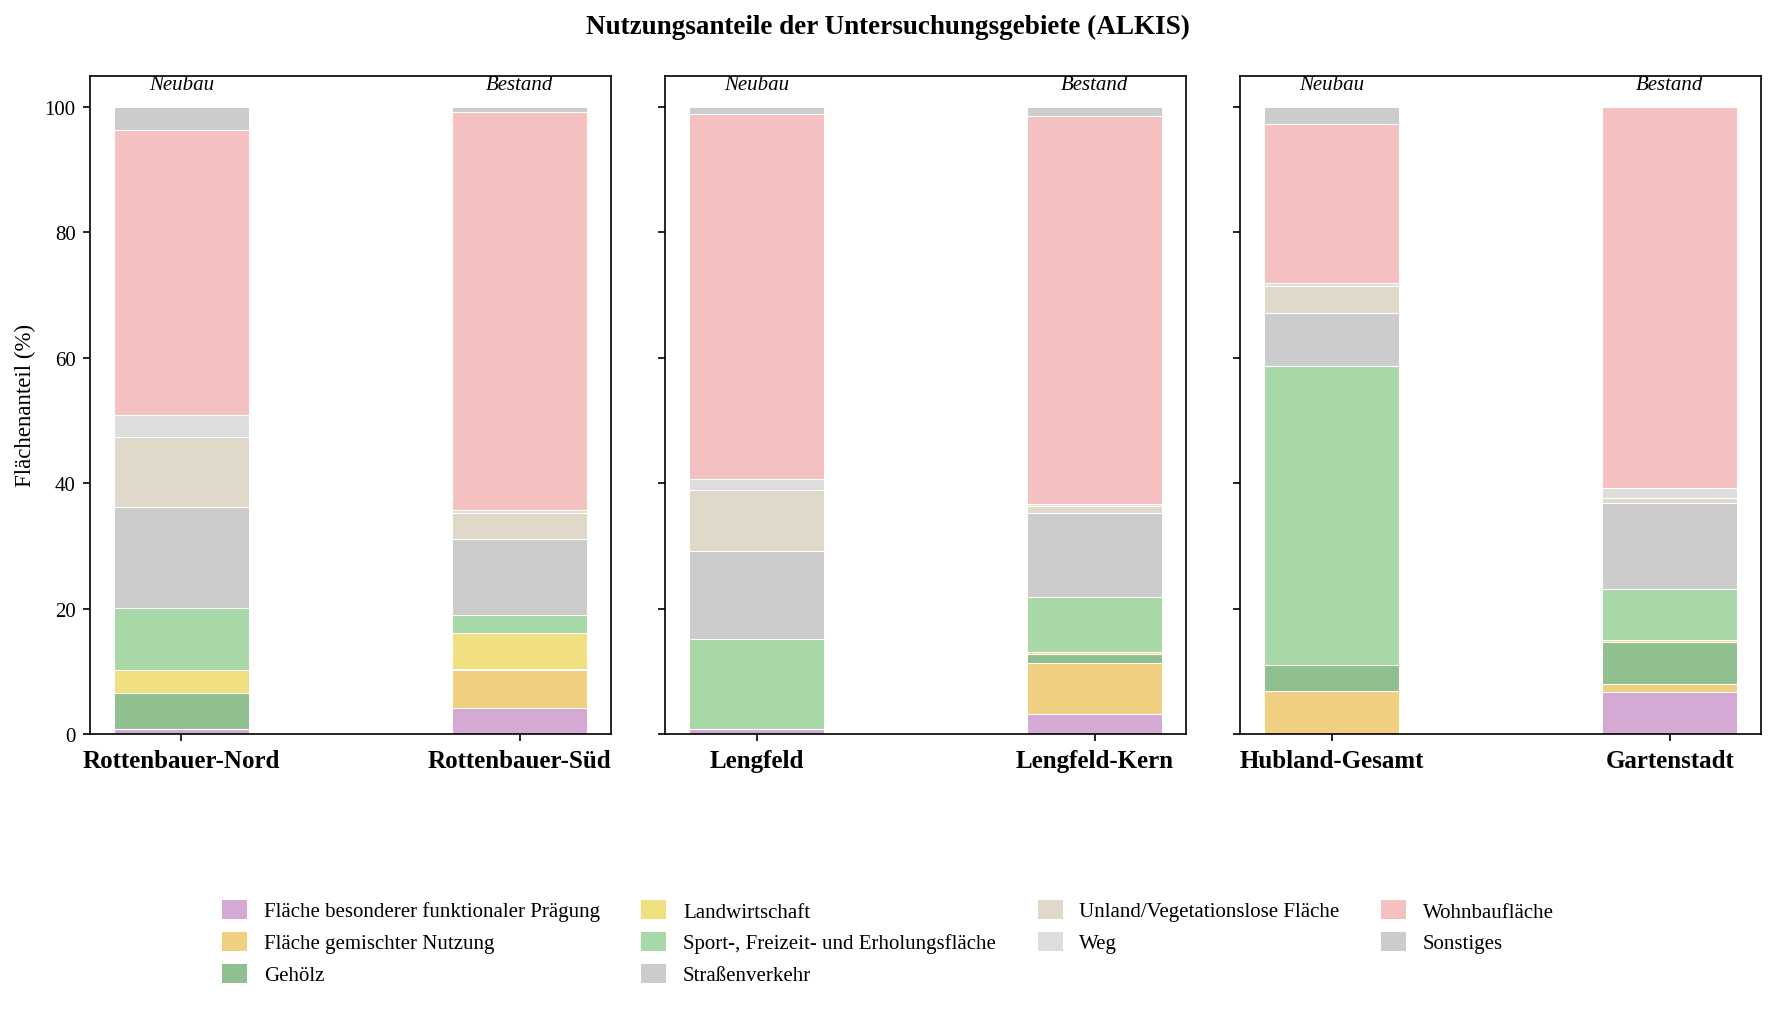

✅ Grafik gespeichert!


In [17]:
# ── Gestapeltes Balkendiagramm: Nutzungsanteile pro Paar ─────────────────────
paare_plot = {
    "Rottenbauer-Nord": gebiete_final["Rottenbauer-Nord"],
    "Rottenbauer-Süd":  gebiete_final["Rottenbauer-Süd"],
    "Lengfeld":         gebiete_final["Lengfeld"],
    "Lengfeld-Kern":    gebiete_final["Lengfeld-Kern"],
    "Hubland-Gesamt":   gebiete_final["Hubland-Gesamt"],
    "Gartenstadt":      gebiete_final["Gartenstadt"],
}

nutzung_data = {}
for name, gdf in paare_plot.items():
    gebiet     = gdf.to_crs(target_crs)
    alkis_clip = gpd.clip(alkis, gebiet)
    gesamt_ha  = gebiet.geometry.area.sum() / 10_000
    anteile = (
        alkis_clip.copy()
        .assign(flaeche_ha=lambda x: x.geometry.area / 10_000)
        .groupby("nutzart")["flaeche_ha"]
        .sum()
        / gesamt_ha * 100
    )
    nutzung_data[name] = anteile

df_nutzung = pd.DataFrame(nutzung_data).fillna(0)

schwelle  = 3
haupt     = df_nutzung[df_nutzung.max(axis=1) >= schwelle]
sonstiges = df_nutzung[df_nutzung.max(axis=1) < schwelle].sum()
df_plot   = pd.concat([haupt, sonstiges.rename("Sonstiges").to_frame().T])

plot_farben = [alkis_farben.get(n, "#cccccc") for n in df_plot.index]

paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]
paar_titel = ["Rottenbauer", "Lengfeld", "Hubland / Gartenstadt"]

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

for ax, (neubau, bestand), titel in zip(axes, paare, paar_titel):
    daten    = df_plot[[neubau, bestand]]
    bottom_n = np.zeros(1)
    bottom_b = np.zeros(1)

    for nutzart, farbe in zip(df_plot.index, plot_farben):
        wert_n = daten.loc[nutzart, neubau]
        wert_b = daten.loc[nutzart, bestand]
        ax.bar([0], [wert_n], bottom=bottom_n, color=farbe,
               edgecolor="white", linewidth=0.5, width=0.4)
        ax.bar([1], [wert_b], bottom=bottom_b, color=farbe,
               edgecolor="white", linewidth=0.5, width=0.4)
        bottom_n += wert_n
        bottom_b += wert_b

     # X-Achse Beschriftung
    ax.set_xticks([0, 1])
    ax.set_xticklabels([neubau, bestand], fontsize=12, color="black", fontweight="bold")

    # Neubau / Bestand Beschriftung über den Balken
    ax.text(0, 102, "Neubau",  ha="center", va="bottom",
            fontsize=10, color="black", fontstyle="italic")
    ax.text(1, 102, "Bestand", ha="center", va="bottom",
            fontsize=10, color="black", fontstyle="italic")

axes[0].set_ylabel("Flächenanteil (%)")

# ── Legende ohne Rahmen ───────────────────────────────────────────────────────
legende = [
    mpatches.Patch(facecolor=alkis_farben.get(n, "#cccccc"),
                   edgecolor="none", label=n)
    for n in df_plot.index
]
fig.legend(
    handles=legende,
    loc="lower center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,        # kein Rahmen
    handlelength=1.2,
    handleheight=1.0,
)

fig.suptitle("Nutzungsanteile der Untersuchungsgebiete (ALKIS)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(f"{grafik_dir_gebiete}/Nutzungsanteile_Paare.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Grafik gespeichert!")